In [184]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
import keras
#from tensorflow.keras import layers, models, optimizers
from math import pi

In [185]:
def apply_diffusion_noise(x):
  time = tf.random.uniform([], 0, 1)
  noise = tf.random.normal(tf.shape(x))
  noised_x = x + noise * time
  flattened_x = tf.reshape(noised_x, [-1])
  time_tensor = tf.reshape(time, [1])
  output_data = tf.concat([flattened_x, time_tensor], axis=-1)
  return output_data, noise * time

def add_noise_ddpm(x):
  """
  Добавляет шум к данным согласно стандартной формуле DDPM.

  Args:
    x: Входные данные (например, изображение).

  Returns:
    Кортеж из двух элементов:
    1. Зашумленные данные и время.
    2. Шум.
  """
  # 1. Генерируем случайное время 't' (скаляр от 0 до 1).
  time = tf.random.uniform([], 0, 1)

  # 2. Определяем расписание шума. Например, линейное.
  # Это значения, которые определяют, как быстро добавляется шум.
  beta_start = 0.0001
  beta_end = 0.02
  
  # Вычисляем бета для данного времени 't'.
  beta_t = beta_start + time * (beta_end - beta_start)
  
  # 3. Вычисляем alpha_bar_t.
  # Здесь мы используем простую формулу для alpha_bar_t
  # на основе beta_t.
  alpha_bar_t = 1.0 - beta_t
  
  # 4. Генерируем нормальный шум того же размера, что и данные.
  noise = tf.random.normal(tf.shape(x))
  
  # 5. Применяем формулу DDPM.
  # Мы используем sqrt(alpha_bar_t) для чистых данных
  # и sqrt(1 - alpha_bar_t) для шума.
  noised_x = tf.sqrt(alpha_bar_t) * x + tf.sqrt(1 - alpha_bar_t) * noise

  # 6. Объединяем зашумленные данные и время в один вектор.
  # Это нужно, чтобы передать их в один входной слой модели.
  flattened_x = tf.reshape(noised_x, [-1])
  time_tensor = tf.reshape(time, [1])
  output_data = tf.concat([flattened_x, time_tensor], axis=-1)

  # 7. Возвращаем объединенный тензор и шум.
  # Модель будет учиться предсказывать 'noise' на основе 'output_data'.
  return output_data, noise


In [186]:
def generate_dataset(N, complexity = 3):
    angle = tf.random.uniform((N, ), 0, complexity)
    r = angle/complexity
    return tf.stack((r*tf.cos(angle*2*pi ), r*tf.sin(angle*2*pi )), -1)

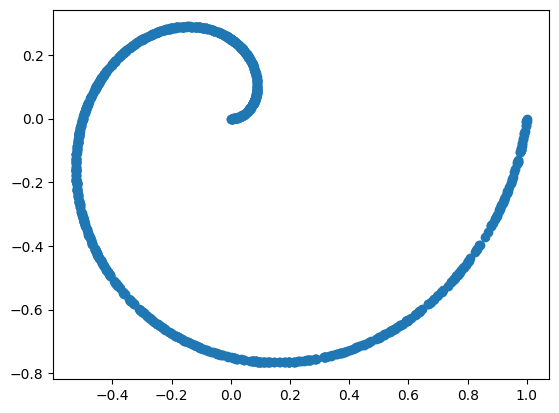

In [187]:
d = generate_dataset(1000, 1)
plt.scatter(d[:, 0], d[:, 1])
plt.show()

In [188]:
data = tf.data.Dataset.from_tensor_slices(d)
data = data.map(add_noise_ddpm)
data = data.batch(32)

In [189]:
def get_model():
    x = keras.Input(shape=(3,))
    y = layers.Dense(16, activation='relu')(x)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(2, activation='linear')(y)
    model = keras.Model(inputs=x, outputs=y)
    return model

In [190]:
model = get_model()
model.build(3)
model.compile(optimizer='adam', loss='mae')


In [191]:
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914 (3.57 KB)

 Trainable params: 914 (3.57 KB)

 Non-trainable params: 0 (0.00 B)

In [201]:
model.fit(data, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5209
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5310 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5261 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5746 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5645 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5361 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5240 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5313 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5269 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5344 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5561 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5088 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5539 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5255 
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

In [193]:
def generate_new_data(model, num_samples=1000, steps=100):
    dt = 1 / steps
    # Generate random input data
    state = tf.random.normal((num_samples, 2))
    # adding time dimension
    # Get the model's predictions
    for step in range(steps):
        t = step * dt
        model_input = tf.concat([state, tf.fill((num_samples, 1), t)], axis=-1)

        state = state - model(model_input)*dt
    return state

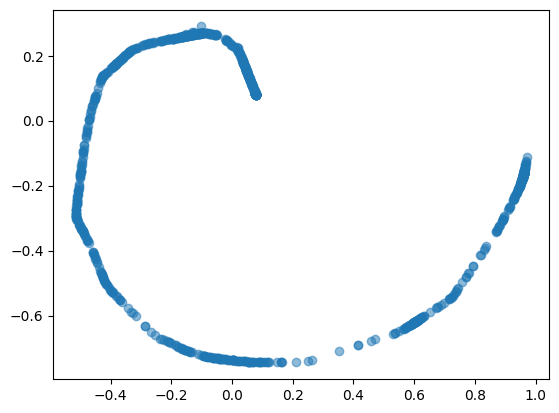

In [212]:
generated_data = generate_new_data(model, num_samples=1000, steps = 100)
plt.scatter(generated_data[:, 0], generated_data[:, 1], alpha=0.5)
plt.show()